/tmp/ipykernel_2274/205386285.py:197: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.94])


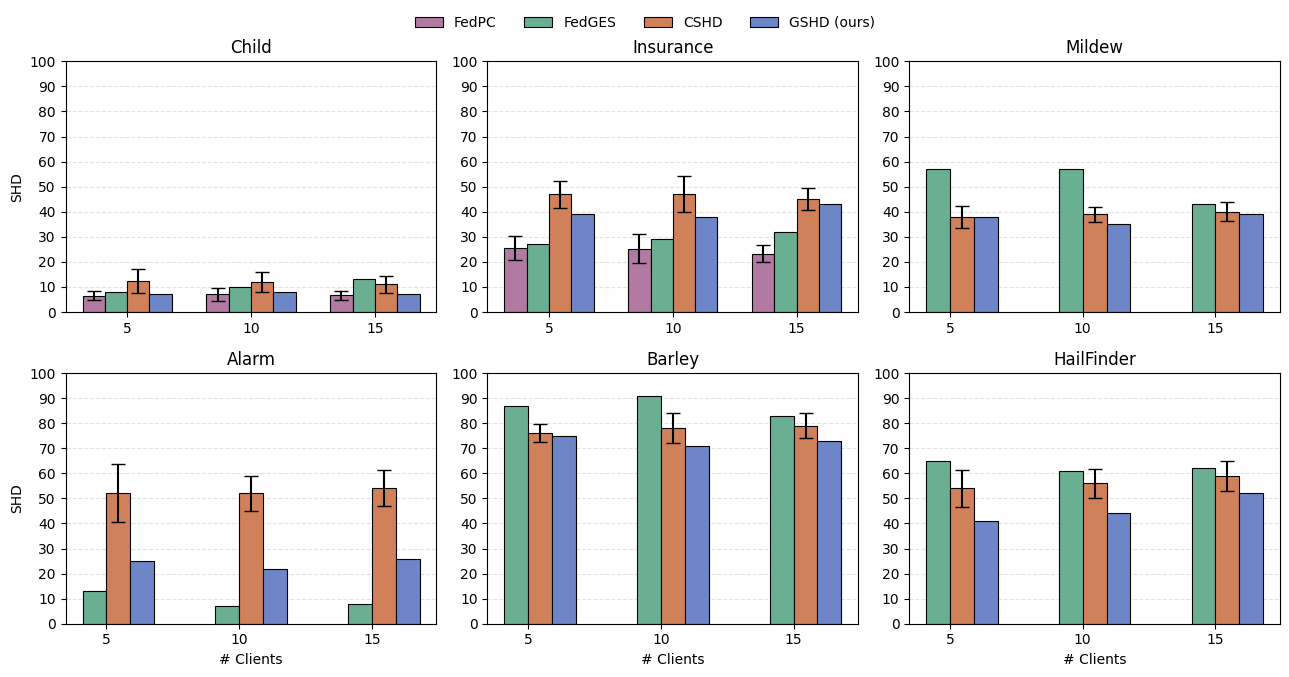

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# -----------------------------
# Client counts
# -----------------------------
clients = ["5", "10", "15"]
x = np.arange(len(clients))
width = 0.25

# -----------------------------
# Data
# -----------------------------
cshd = {
    "Sachs": [0,0,0],
    "Child": [12.4, 12.0, 11.0],
    "HailFinder": [54, 56, 59],
    "Hepar2": [0,0,0]
}

cshd_std = {
    "Sachs": [0,0,0],
    "Child": [4.67, 4.00, 3.464],
    "HailFinder": [7.416, 5.831, 5.916],
    "Hepar2": [0,0,0]
}

gshd = {
    "Sachs": [0,0,0],
    "Child": [7, 8, 7],
    "HailFinder": [41, 44, 52],
    "Hepar2": [0,0,0]
}

fedges = {
    "Child":      [8, 10, 13],
    "Insurance":  [27, 29, 32],
    "Mildew":     [57, 57, 43],
    "Alarm":      [13, 7, 8],
    "Barley":     [87, 91, 83],
    "HailFinder": [65, 61, 62]
}

fedpc_mean = {
    "Child":      [6.545, 7, 6.6],
    "Insurance":  [25.5, 25.3, 23.2],
    "Mildew":     [np.nan, np.nan, np.nan],
    "Alarm":      [np.nan, np.nan, np.nan],
    "Barley":     [np.nan, np.nan, np.nan],
    "HailFinder": [np.nan, np.nan, np.nan]
}

titles = list(cshd.keys())

# Colors
cshd_color   = "#D08159"   # terracotta
fedges_color = "#6BAF92"   # sea green
gshd_color   = "#6E86C7"   # steel blue
fedpc_color  = "#B279A2"   # dusty mauve

width = 0.18

fig, axes = plt.subplots(
    2,
    3,
    figsize=(13, 7),
    constrained_layout=True
)

axes = axes.flatten()

for i, network in enumerate(titles):

    ax = axes[i]

    mean = np.array(cshd[network], dtype=float)
    std = np.array(cshd_std[network], dtype=float)

    global_shd = np.array(gshd[network], dtype=float)
    fedges_shd = np.array(fedges[network], dtype=float)

    fedpc_mean_vals = np.array(fedpc_mean[network], dtype=float)
    fedpc_std_vals  = np.array(fedpc_std[network], dtype=float)

    # -----------------------------
    # FedPC (leftmost)
    # -----------------------------
    ax.bar(
        x - 1.5 * width,
        fedpc_mean_vals,
        width,
        yerr=fedpc_std_vals,
        capsize=5,
        color=fedpc_color,
        edgecolor="black",
        linewidth=0.8,
        label="FedPC",
    )

    # -----------------------------
    # FedGES
    # -----------------------------
    ax.bar(
        x - 0.5 * width,
        fedges_shd,
        width,
        color=fedges_color,
        edgecolor="black",
        linewidth=0.8,
        label="FedGES",
    )

    # -----------------------------
    # CSHD
    # -----------------------------
    ax.bar(
        x + 0.5 * width,
        mean,
        width,
        yerr=std,
        capsize=5,
        color=cshd_color,
        edgecolor="black",
        linewidth=0.8,
        label="CSHD",
    )

    # -----------------------------
    # GSHD (rightmost)
    # -----------------------------
    ax.bar(
        x + 1.5 * width,
        global_shd,
        width,
        color=gshd_color,
        edgecolor="black",
        linewidth=0.8,
        label="GSHD (ours)",
    )

    ax.set_title(network, fontsize=12)

    # Show x-label only on bottom row
    if i >= 3:
        ax.set_xlabel("# Clients")

    # Show y-label only on first column
    if i % 3 == 0:
        ax.set_ylabel("SHD")

    ax.set_xticks(x)
    ax.set_xticklabels(clients)

    ax.set_ylim(0, 100)
    ax.yaxis.set_major_locator(MultipleLocator(10))

    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

    # # Show legend only once
    # if i == 0:
    #     ax.legend(
    #         loc="upper center",
    #         bbox_to_anchor=(1.05, 1.22),
    #         ncol=4,
    #         frameon=False,
    #         fontsize=9,
    #     )
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.97),
    ncol=4,
    frameon=False,
    fontsize=10,
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

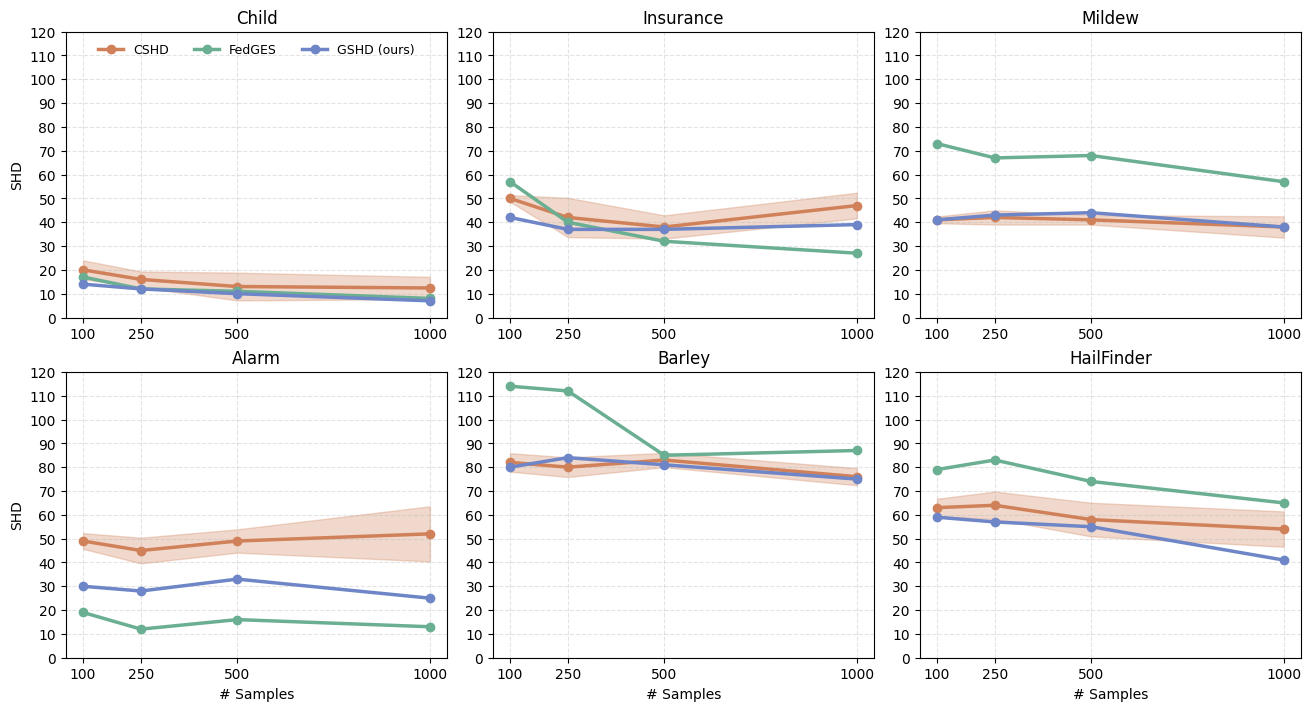

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# -----------------------------
# Dataset sizes
# -----------------------------
sizes = np.array([100, 250, 500, 1000])

# -----------------------------
# CSHD
# -----------------------------
cshd = {
    "Child":      [20, 16, 13, 12.4],
    "Insurance":  [50, 42, 38, 47],
    "Mildew":     [41, 42, 41, 38],
    "Alarm":      [49, 45, 49, 52],
    "Barley":     [82, 80, 83, 76],
    "HailFinder": [63, 64, 58, 54],
}

cshd_std = {
    "Child":      [4.0, 3.316, 5.831, 4.67],
    "Insurance":  [1.414, 8.246, 4.899, 5.385],
    "Mildew":     [1.414, 3.0, 2.0, 4.472],
    "Alarm":      [3.317, 5.385, 4.899, 11.576],
    "Barley":     [3.873, 4.123, 3.0, 3.606],
    "HailFinder": [3.742, 5.745, 7.071, 7.416],
}

# -----------------------------
# GSHD
# -----------------------------
gshd = {
    "Child":      [14, 12, 10, 7],
    "Insurance":  [42, 37, 37, 39],
    "Mildew":     [41, 43, 44, 38],
    "Alarm":      [30, 28, 33, 25],
    "Barley":     [80, 84, 81, 75],
    "HailFinder": [59, 57, 55, 41],
}

# -----------------------------
# FedGES (fill later)
# -----------------------------
fedges = {
    "Child":      [17, 12, 11, 8],
    "Insurance":  [57, 40, 32, 27],
    "Mildew":     [73, 67, 68, 57],
    "Alarm":      [19, 12, 16, 13],
    "Barley":     [114, 112, 85, 87],
    "HailFinder": [79, 83, 74, 65],
}

titles = list(cshd.keys())

cshd_color   = "#D08159"   # terracotta
fedges_color = "#6BAF92"   # sea green
gshd_color   = "#6E86C7"   # steel blue

fig, axes = plt.subplots(
    2, 3,
    figsize=(13, 7),
    constrained_layout=True
)

axes = axes.flatten()

for i, network in enumerate(titles):

    ax = axes[i]

    mean = np.array(cshd[network], dtype=float)
    std = np.array(cshd_std[network], dtype=float)
    fed = np.array(fedges[network], dtype=float)
    g = np.array(gshd[network], dtype=float)

    # CSHD
    ax.plot(
        sizes,
        mean,
        color=cshd_color,
        linewidth=2.5,
        marker='o',
        markersize=6,
        label="CSHD",
    )

    # Variance band
    ax.fill_between(
        sizes,
        mean - std,
        mean + std,
        color=cshd_color,
        alpha=0.30,
    )

    # FedGES
    ax.plot(
        sizes,
        fed,
        color=fedges_color,
        linewidth=2.5,
        marker='o',
        markersize=6,
        label="FedGES",
    )

    # GSHD
    ax.plot(
        sizes,
        g,
        color=gshd_color,
        linewidth=2.5,
        marker='o',
        markersize=6,
        label="GSHD (ours)",
    )

    ax.set_title(network)
    if i >= 3:      # bottom row
        ax.set_xlabel("# Samples")
    else:
        ax.set_xlabel("")

    if i % 3 == 0:      # first column
        ax.set_ylabel("SHD")
    else:
        ax.set_ylabel("")

    ax.set_xticks(sizes)

    ax.set_ylim(0, 120)
    ax.yaxis.set_major_locator(MultipleLocator(10))

    ax.grid(True, linestyle="--", alpha=0.35)

    if i == 0:
        ax.legend(
            loc="upper center",
            ncol=3,
            frameon=False,
            fontsize=9,
        )

plt.show()

/tmp/ipykernel_13677/2652967007.py:117: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.94])


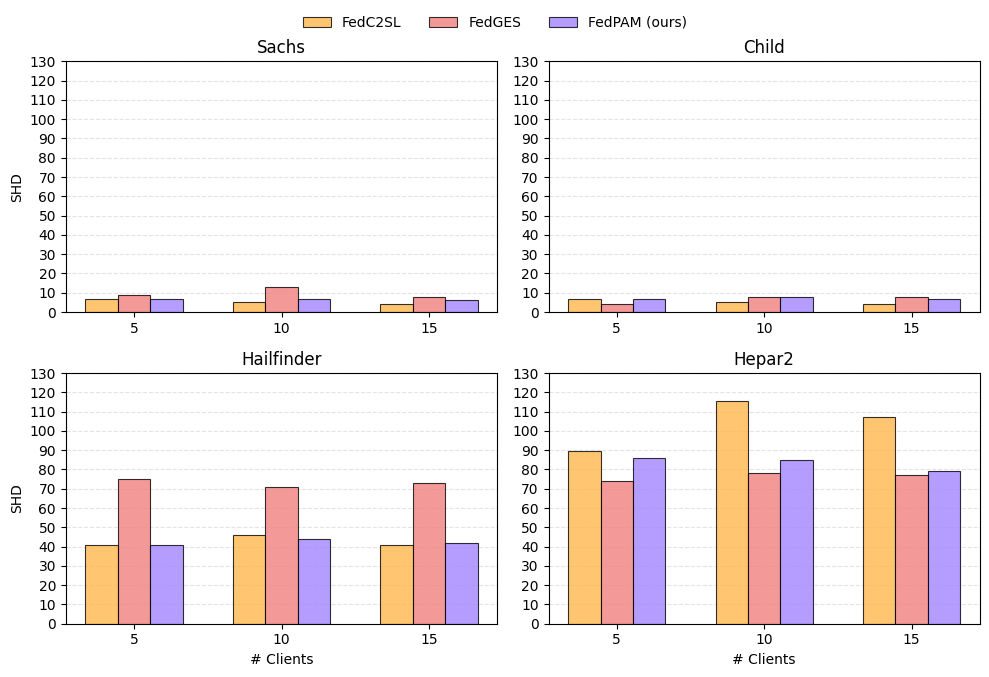

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

clients = ["5", "10", "15"]
x = np.arange(len(clients))

gshd = {
    "Sachs": [7, 7, 6],
    "Child": [7, 8, 7],
    "Hailfinder": [41, 44, 42],
    "Hepar2": [86, 85, 79]
}

fedges = {
    "Sachs": [9, 13, 8],
    "Child": [4, 8, 8],
    "Hailfinder": [75, 71, 73],
    "Hepar2": [74, 78, 77]
}

fedpc_mean = {
    "Sachs": [7, 5, 4.4],
    "Child": [7, 5, 4],
    "Hailfinder": [41, 46.1, 41],
    "Hepar2": [89.8, 115.6, 107.1]
}

titles = list(gshd.keys())

fedpc_color = "#ffb74d"
fedges_color = "#f08180"
fedpam_color = "#a285ff"

width = 0.22

fig, axes = plt.subplots(
    2,
    2,
    figsize=(10, 7),
    constrained_layout=True
)

axes = axes.flatten()

for i, network in enumerate(titles):

    ax = axes[i]

    fedpam_shd = np.array(gshd[network], dtype=float)
    fedges_shd = np.array(fedges[network], dtype=float)
    fedpc_mean_vals = np.array(fedpc_mean[network], dtype=float)

    ax.bar(
        x - width,
        fedpc_mean_vals,
        width,
        color=fedpc_color,
        edgecolor="black",
        linewidth=0.8,
        alpha=0.8,
        label="FedC2SL"
    )

    ax.bar(
        x,
        fedges_shd,
        width,
        color=fedges_color,
        edgecolor="black",
        linewidth=0.8,
        alpha=0.8,
        label="FedGES"
    )

    ax.bar(
        x + width,
        fedpam_shd,
        width,
        color=fedpam_color,
        edgecolor="black",
        linewidth=0.8,
        alpha=0.8,
        label="FedPAM (ours)"
    )

    ax.set_title(network, fontsize=12)

    if i >= 2:
        ax.set_xlabel("# Clients")

    if i % 2 == 0:
        ax.set_ylabel("SHD")

    ax.set_xticks(x)
    ax.set_xticklabels(clients)

    # Same y-axis range for all charts
    ax.set_ylim(0, 130)
    ax.yaxis.set_major_locator(MultipleLocator(10))

    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.97),
    ncol=3,
    frameon=False,
    fontsize=10
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("IMPACT_NUM_CLIENTS.png", dpi=1000, bbox_inches="tight")
plt.show()

/tmp/ipykernel_4891/594123581.py:123: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


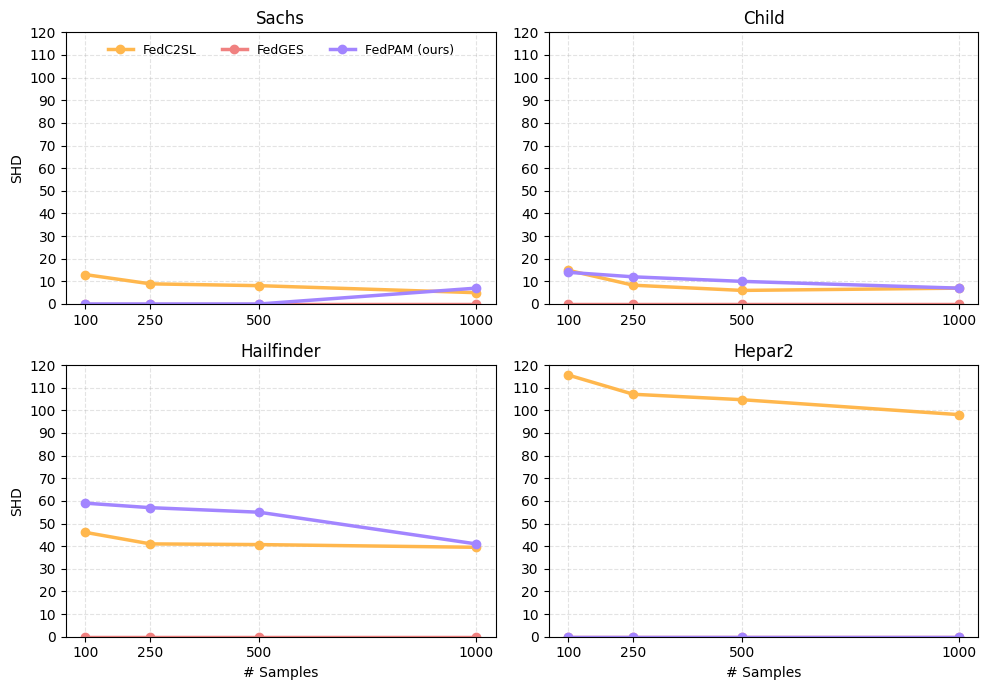

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# -----------------------------
# Dataset sizes
# -----------------------------
sizes = np.array([100, 250, 500, 1000])

# -----------------------------
# FedPC (renamed from CSHD)
# -----------------------------
fedpc = {
    "Sachs":      [13, 8.9, 8.1, 5],
    "Child":      [14.9, 8.3, 6, 7],
    "Hailfinder":      [46.1, 41, 40.7, 39.5],
    "Hepar2":  [115.6, 107.1, 104.7, 98.1],
}


# -----------------------------
# FedPAM (renamed from GSHD)
# -----------------------------
fedpam = {
    "Sachs":       [0, 0, 0, 7],
    "Child":      [14, 12, 10, 7],
    "Hailfinder":     [59, 57, 55, 41],
    "Hepar2":  [0, 0, 0, 0],
}

# -----------------------------
# FedGES
# -----------------------------
fedges = {
    "Sachs":       [0, 0, 0, 0],
    "Child":      [0, 0, 0, 0],
    "Hailfinder":      [0, 0, 0, 0],
    "Hepar2":  [0, 0, 0, 0],
}

titles = list(fedpc.keys())

fedpc_color = "#ffb74d"
fedges_color = "#f08180"
fedpam_color = "#a285ff"

fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 7),
    constrained_layout=True
)

axes = axes.flatten()

for i, network in enumerate(titles):

    ax = axes[i]

    mean = np.array(fedpc[network], dtype=float)
    fed = np.array(fedges[network], dtype=float)
    pam = np.array(fedpam[network], dtype=float)

    # FedPC
    ax.plot(
        sizes,
        mean,
        color=fedpc_color,
        linewidth=2.5,
        marker='o',
        markersize=6,
        label="FedC2SL",
    )

    # FedGES
    ax.plot(
        sizes,
        fed,
        color=fedges_color,
        linewidth=2.5,
        marker='o',
        markersize=6,
        label="FedGES",
    )

    # FedPAM
    ax.plot(
        sizes,
        pam,
        color=fedpam_color,
        linewidth=2.5,
        marker='o',
        markersize=6,
        label="FedPAM (ours)",
    )

    ax.set_title(network, fontsize=12)
    
    if i >= 2:      # bottom row
        ax.set_xlabel("# Samples")
    else:
        ax.set_xlabel("")

    if i % 2 == 0:      # first column
        ax.set_ylabel("SHD")
    else:
        ax.set_ylabel("")

    ax.set_xticks(sizes)

    ax.set_ylim(0, 120)
    ax.yaxis.set_major_locator(MultipleLocator(10))

    ax.grid(True, linestyle="--", alpha=0.35)

    if i == 0:
        ax.legend(
            loc="upper center",
            ncol=3,
            frameon=False,
            fontsize=9,
        )

plt.tight_layout()
plt.savefig('IMPACT_NUM_SAMPLES.png', dpi=1000, bbox_inches='tight')
plt.show()

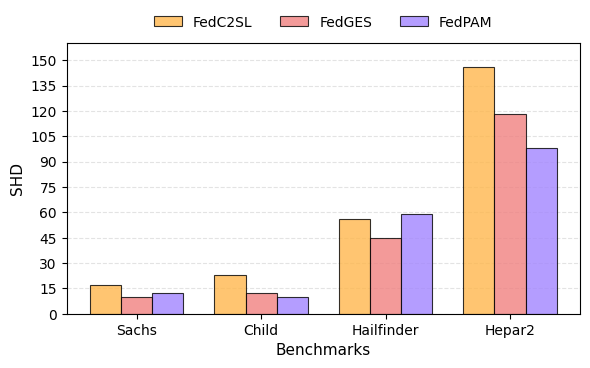

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# Benchmarks
benchmarks = ["Sachs", "Child", "Hailfinder", "Hepar2"]
x = np.arange(len(benchmarks))

# Data
fedpam = [12, 10, 59, 98]
fedc2sl = [17.1, 23, 56, 146]
fedges = [10, 12, 45, 118]
# Colors
fedc2sl_color = "#ffb74d"
fedges_color = "#f08180"
fedpam_color = "#a285ff"

width = 0.25

fig, ax = plt.subplots(figsize=(6, 4))

# Plot bars
ax.bar(
    x - width,
    fedc2sl,
    width,
    color=fedc2sl_color,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.8,
    label="FedC2SL",
)

ax.bar(
    x,
    fedges,
    width,
    color=fedges_color,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.8,
    label="FedGES",
)

ax.bar(
    x + width,
    fedpam,
    width,
    color=fedpam_color,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.8,
    label="FedPAM",
)

# Labels and formatting
ax.set_xlabel("Benchmarks", fontsize=11)
ax.set_ylabel("SHD", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(benchmarks)
ax.set_ylim(0, 160)
ax.yaxis.set_major_locator(MultipleLocator(15))

ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15),  # move legend up
    ncol=3,
    frameon=False,
    fontsize=10,
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('heterogeneous_data.png', dpi=1000, bbox_inches='tight')
plt.show()

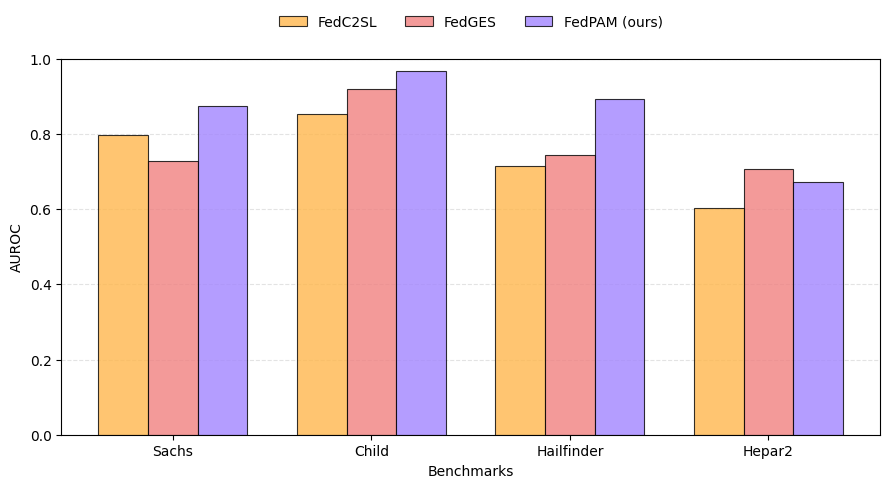

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

benchmarks = ["Sachs", "Child", "Hailfinder", "Hepar2"]
x = np.arange(len(benchmarks))

# Initialize AUROC values to 0
fedc2sl_auroc = [0.796, 0.854, 0.715, 0.603]
fedges_auroc = [0.727, 0.92, 0.745, 0.706]
fedpam_auroc = [0.874, 0.968, 0.893, 0]

fedc2sl_color = "#ffb74d"
fedges_color = "#f08180"
fedpam_color = "#a285ff"

width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    x - width,
    fedc2sl_auroc,
    width,
    color=fedc2sl_color,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.8,
    label="FedC2SL"
)

ax.bar(
    x,
    fedges_auroc,
    width,
    color=fedges_color,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.8,
    label="FedGES"
)

ax.bar(
    x + width,
    fedpam_auroc,
    width,
    color=fedpam_color,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.8,
    label="FedPAM (ours)"
)

ax.set_xlabel("Benchmarks")
ax.set_ylabel("AUROC")

ax.set_xticks(x)
ax.set_xticklabels(benchmarks)

ax.set_ylim(0, 1.0)
ax.yaxis.set_major_locator(MultipleLocator(0.2))

ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15),
    ncol=3,
    frameon=False
)

plt.tight_layout()
plt.savefig("AUROC.png", dpi=1000, bbox_inches="tight")
plt.show()

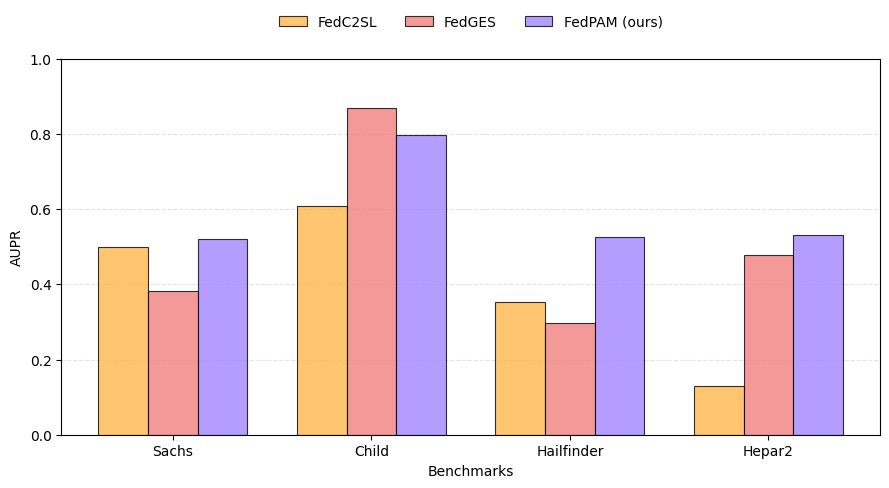

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

benchmarks = ["Sachs", "Child", "Hailfinder", "Hepar2"]
x = np.arange(len(benchmarks))

# Initialize AUPR values to 0
fedc2sl_aupr = [0.499, 0.608, 0.354, 0.129]
fedges_aupr = [0.381, 0.869, 0.298, 0.479]
fedpam_aupr = [0.521, 0.798, 0.527, 0.53]

fedc2sl_color = "#ffb74d"
fedges_color = "#f08180"
fedpam_color = "#a285ff"

width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    x - width,
    fedc2sl_aupr,
    width,
    color=fedc2sl_color,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.8,
    label="FedC2SL"
)

ax.bar(
    x,
    fedges_aupr,
    width,
    color=fedges_color,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.8,
    label="FedGES"
)

ax.bar(
    x + width,
    fedpam_aupr,
    width,
    color=fedpam_color,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.8,
    label="FedPAM (ours)"
)

ax.set_xlabel("Benchmarks")
ax.set_ylabel("AUPR")

ax.set_xticks(x)
ax.set_xticklabels(benchmarks)

ax.set_ylim(0, 1.0)
ax.yaxis.set_major_locator(MultipleLocator(0.2))

ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15),
    ncol=3,
    frameon=False
)

plt.tight_layout()
plt.savefig("AUPR.png", dpi=1000, bbox_inches="tight")
plt.show()

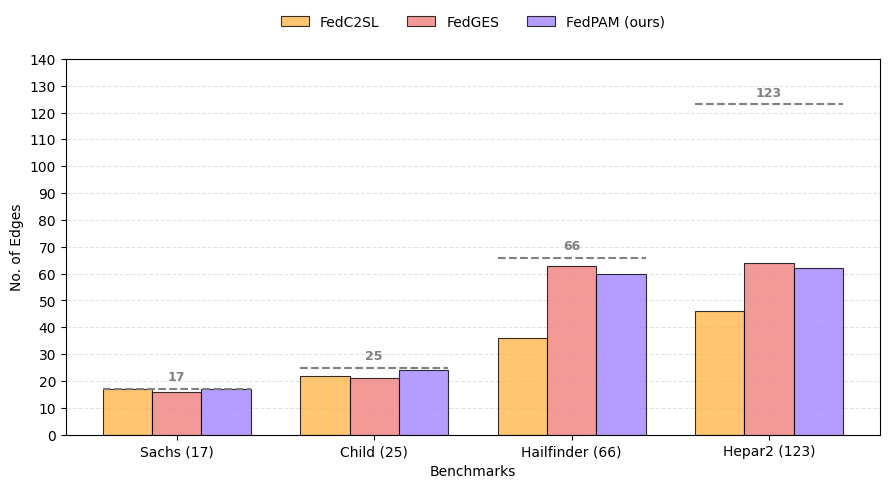

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

benchmarks = ["Sachs (17)", "Child (25)", "Hailfinder (66)", "Hepar2 (123)"]
true_edges = [17, 25, 66, 123]

x = np.arange(len(benchmarks))

fedc2sl_edges = [17, 22, 36, 46]
fedges_edges = [16, 21, 63, 64]
fedpam_edges = [17, 24, 60, 62]

fedc2sl_color = "#ffb74d"
fedges_color = "#f08180"
fedpam_color = "#a285ff"

width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))

# Bars
bars_c2sl = ax.bar(
    x - width,
    fedc2sl_edges,
    width,
    color=fedc2sl_color,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.8,
    label="FedC2SL"
)

bars_ges = ax.bar(
    x,
    fedges_edges,
    width,
    color=fedges_color,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.8,
    label="FedGES"
)

bars_pam = ax.bar(
    x + width,
    fedpam_edges,
    width,
    color=fedpam_color,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.8,
    label="FedPAM (ours)"
)

# Grey dashed reference line for the true number of edges
for i, edge_count in enumerate(true_edges):

    # Span from the left edge of the first bar
    # to the right edge of the third bar
    left = x[i] - width - width / 2
    right = x[i] + width + width / 2

    ax.hlines(
        y=edge_count,
        xmin=left,
        xmax=right,
        colors="grey",
        linestyles="--",
        linewidth=1.5,
        zorder=5
    )

    # Annotate the true number of edges
    ax.text(
        x[i],
        edge_count + 2,
        str(edge_count),
        ha="center",
        va="bottom",
        fontsize=9,
        color="grey",
        fontweight="bold"
    )

ax.set_xlabel("Benchmarks")
ax.set_ylabel("No. of Edges")

ax.set_xticks(x)
ax.set_xticklabels(benchmarks)

# Increased to show Hepar2 true edge count = 123
ax.set_ylim(0, 140)
ax.yaxis.set_major_locator(MultipleLocator(10))

ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15),
    ncol=3,
    frameon=False
)

plt.tight_layout()
plt.savefig("NUM_EDGES.png", dpi=1000, bbox_inches="tight")
plt.show()

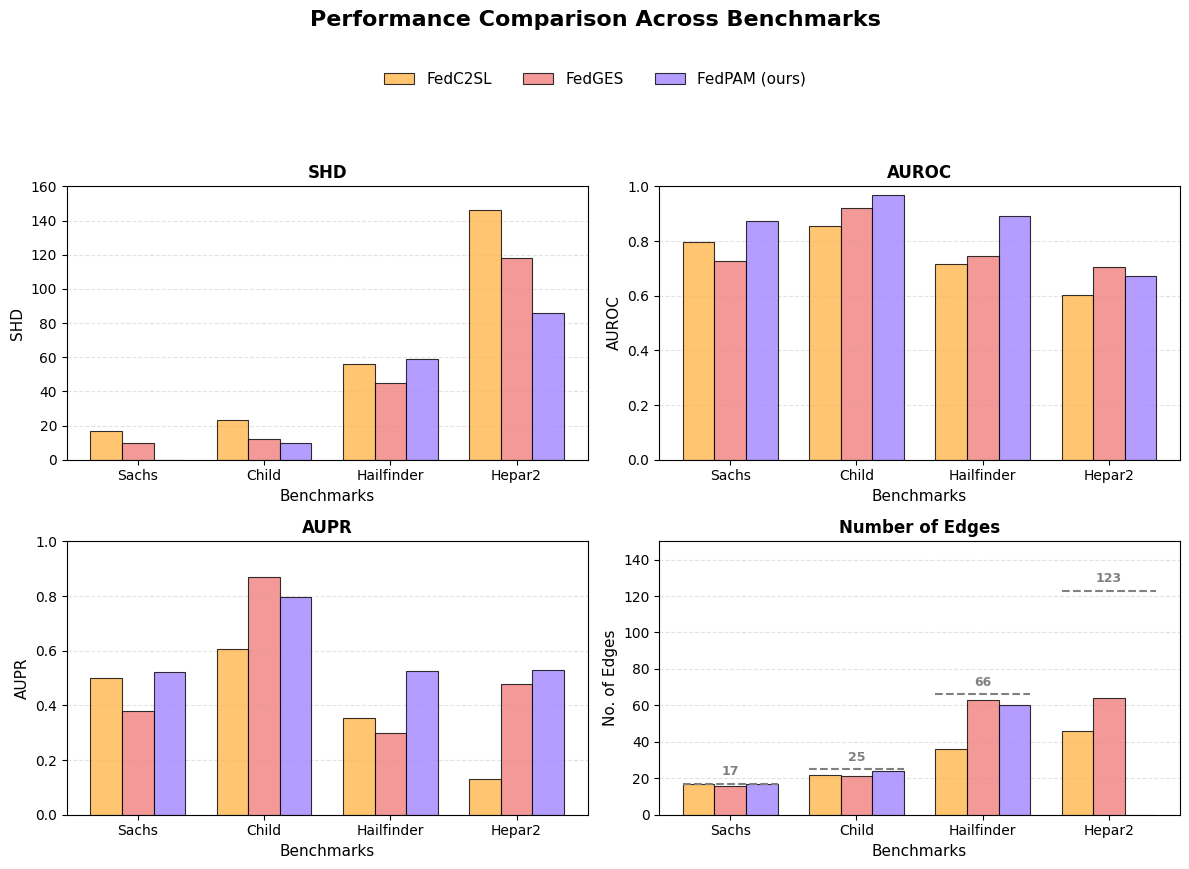

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# ==========================================
# Common settings
# ==========================================

benchmarks = ["Sachs", "Child", "Hailfinder", "Hepar2"]
x = np.arange(len(benchmarks))

# Colors
fedc2sl_color = "#ffb74d"
fedges_color = "#f08180"
fedpam_color = "#a285ff"

width = 0.25


# ==========================================
# Data
# ==========================================

# ---------- SHD ----------
fedc2sl_shd = [17.1, 23, 56, 146]
fedges_shd = [10, 12, 45, 118]
fedpam_shd = [0, 10, 59, 86]


# ---------- AUROC ----------
fedc2sl_auroc = [0.796, 0.854, 0.715, 0.603]
fedges_auroc = [0.727, 0.920, 0.745, 0.706]
fedpam_auroc = [0.874, 0.968, 0.893, 0.673]


# ---------- AUPR ----------
fedc2sl_aupr = [0.499, 0.608, 0.354, 0.129]
fedges_aupr = [0.381, 0.869, 0.298, 0.479]
fedpam_aupr = [0.521, 0.798, 0.527, 0.53]


# ---------- Number of Edges ----------
true_edges = [17, 25, 66, 123]

fedc2sl_edges = [17, 22, 36, 46]
fedges_edges = [16, 21, 63, 64]
fedpam_edges = [17, 24, 60, 0]


# ==========================================
# Create 2x2 subplot
# ==========================================

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# --------------------------------------------------
# Helper function for grouped bar plots
# --------------------------------------------------

def plot_grouped_bars(
    ax,
    data_c2sl,
    data_ges,
    data_pam,
    ylabel,
    title,
    ylim=None,
    y_locator=None,
):
    
    ax.bar(
        x - width,
        data_c2sl,
        width,
        color=fedc2sl_color,
        edgecolor="black",
        linewidth=0.8,
        alpha=0.8,
        label="FedC2SL",
    )

    ax.bar(
        x,
        data_ges,
        width,
        color=fedges_color,
        edgecolor="black",
        linewidth=0.8,
        alpha=0.8,
        label="FedGES",
    )

    ax.bar(
        x + width,
        data_pam,
        width,
        color=fedpam_color,
        edgecolor="black",
        linewidth=0.8,
        alpha=0.8,
        label="FedPAM (ours)",
    )

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Benchmarks", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)

    ax.set_xticks(x)
    ax.set_xticklabels(benchmarks)

    if ylim is not None:
        ax.set_ylim(*ylim)

    if y_locator is not None:
        ax.yaxis.set_major_locator(MultipleLocator(y_locator))

    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)


# ==========================================
# 1. SHD
# ==========================================

plot_grouped_bars(
    axes[0, 0],
    fedc2sl_shd,
    fedges_shd,
    fedpam_shd,
    ylabel="SHD",
    title="SHD",
    ylim=(0, 160),
    y_locator=20,
)


# ==========================================
# 2. AUROC
# ==========================================

plot_grouped_bars(
    axes[0, 1],
    fedc2sl_auroc,
    fedges_auroc,
    fedpam_auroc,
    ylabel="AUROC",
    title="AUROC",
    ylim=(0, 1.0),
    y_locator=0.2,
)


# ==========================================
# 3. AUPR
# ==========================================

plot_grouped_bars(
    axes[1, 0],
    fedc2sl_aupr,
    fedges_aupr,
    fedpam_aupr,
    ylabel="AUPR",
    title="AUPR",
    ylim=(0, 1.0),
    y_locator=0.2,
)


# ==========================================
# 4. Number of Edges
# ==========================================

ax = axes[1, 1]

# Plot grouped bars
ax.bar(
    x - width,
    fedc2sl_edges,
    width,
    color=fedc2sl_color,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.8,
    label="FedC2SL",
)

ax.bar(
    x,
    fedges_edges,
    width,
    color=fedges_color,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.8,
    label="FedGES",
)

ax.bar(
    x + width,
    fedpam_edges,
    width,
    color=fedpam_color,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.8,
    label="FedPAM (ours)",
)

# True number of edges reference lines
for i, edge_count in enumerate(true_edges):

    left = x[i] - width - width / 2
    right = x[i] + width + width / 2

    ax.hlines(
        y=edge_count,
        xmin=left,
        xmax=right,
        colors="grey",
        linestyles="--",
        linewidth=1.5,
        zorder=5,
    )

    ax.text(
        x[i],
        edge_count + 3,
        str(edge_count),
        ha="center",
        va="bottom",
        fontsize=9,
        color="grey",
        fontweight="bold",
    )

ax.set_title("Number of Edges", fontsize=12, fontweight="bold")
ax.set_xlabel("Benchmarks", fontsize=11)
ax.set_ylabel("No. of Edges", fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(benchmarks)

ax.set_ylim(0, 150)
ax.yaxis.set_major_locator(MultipleLocator(20))

ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)


# ==========================================
# Shared legend
# ==========================================

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    frameon=False,
    fontsize=11,
)


# ==========================================
# Final layout
# ==========================================

fig.suptitle(
    "Performance Comparison Across Benchmarks",
    fontsize=16,
    fontweight="bold",
    y=1.08,
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig(
    "performance_comparison_2x2.png",
    dpi=1000,
    bbox_inches="tight",
)

plt.show()

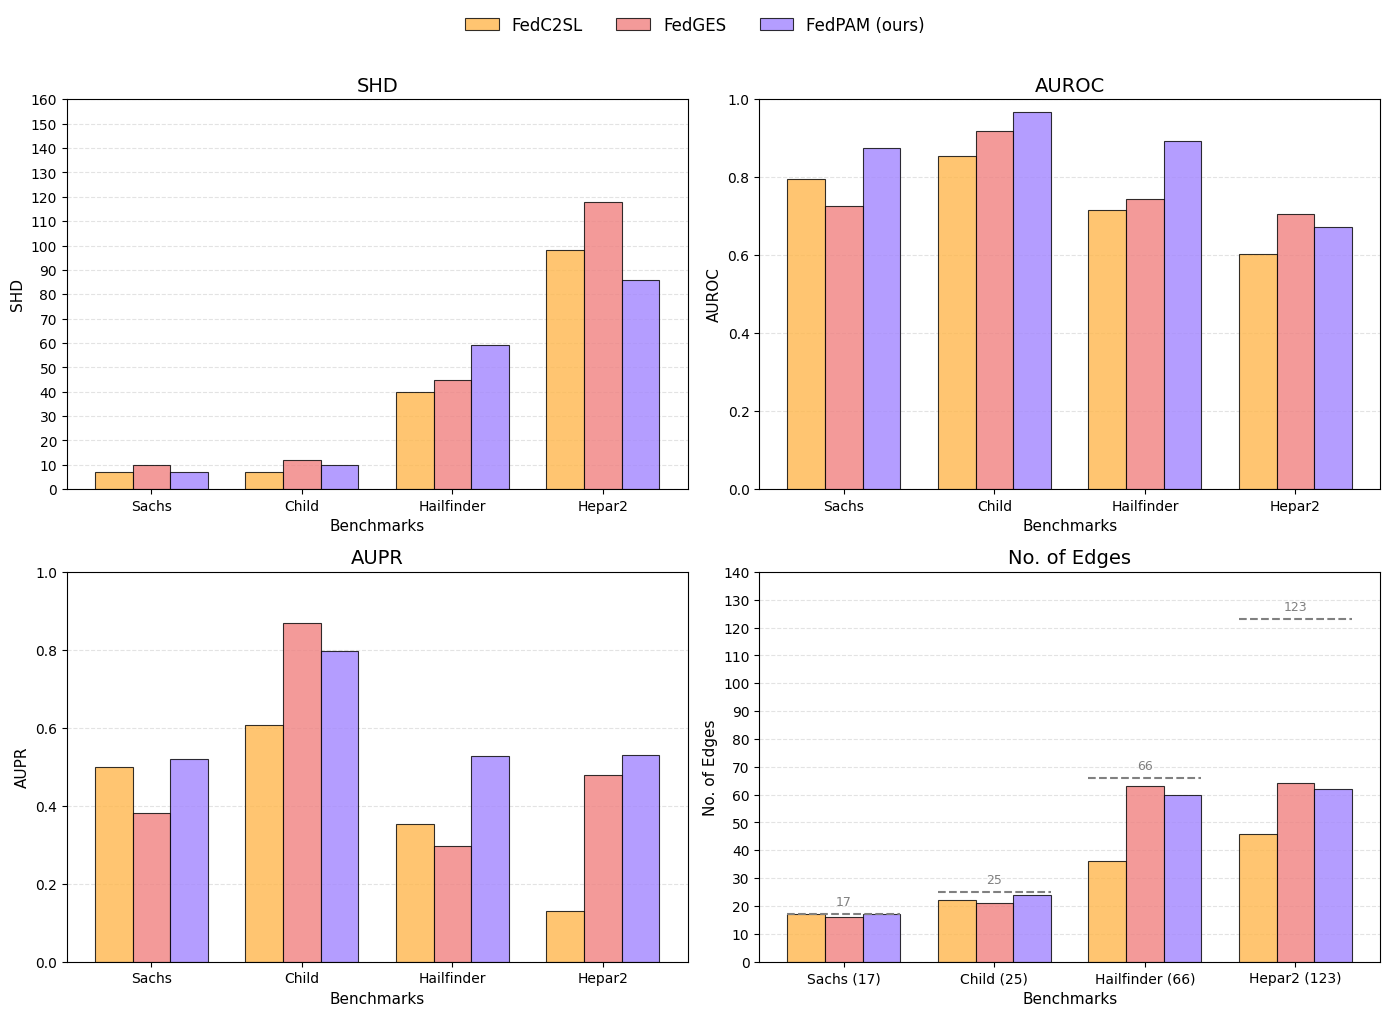

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# ============================================================
# Data
# ============================================================

benchmarks = ["Sachs", "Child", "Hailfinder", "Hepar2"]
benchmarks_edges = ["Sachs (17)", "Child (25)", "Hailfinder (66)", "Hepar2 (123)"]

x = np.arange(len(benchmarks))
width = 0.25

# SHD
fedc2sl_shd = [7, 7, 39.9, 98.1]
fedges_shd = [10, 12, 45, 118]
fedpam_shd = [7, 10, 59, 86]


# ---------- AUROC ----------
fedc2sl_auroc = [0.796, 0.854, 0.715, 0.603]
fedges_auroc = [0.727, 0.920, 0.745, 0.706]
fedpam_auroc = [0.874, 0.968, 0.893, 0.673]


# ---------- AUPR ----------
fedc2sl_aupr = [0.499, 0.608, 0.354, 0.129]
fedges_aupr = [0.381, 0.869, 0.298, 0.479]
fedpam_aupr = [0.521, 0.798, 0.527, 0.53]


# ---------- Number of Edges ----------
true_edges = [17, 25, 66, 123]

fedc2sl_edges = [17, 22, 36, 46]
fedges_edges = [16, 21, 63, 64]
fedpam_edges = [17, 24, 60, 62]


# ============================================================
# Colors
# ============================================================

fedc2sl_color = "#ffb74d"
fedges_color = "#f08180"
fedpam_color = "#a285ff"


# ============================================================
# Create 2x2 subplot
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ============================================================
# 1. SHD
# ============================================================

ax = axes[0, 0]

ax.bar(
    x - width,
    fedc2sl_shd,
    width,
    color=fedc2sl_color,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.8,
    label="FedC2SL"
)

ax.bar(
    x,
    fedges_shd,
    width,
    color=fedges_color,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.8,
    label="FedGES"
)

ax.bar(
    x + width,
    fedpam_shd,
    width,
    color=fedpam_color,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.8,
    label="FedPAM (ours)"
)

ax.set_title("SHD", fontsize=14)
ax.set_xlabel("Benchmarks", fontsize=11)
ax.set_ylabel("SHD", fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(benchmarks)

ax.set_ylim(0, 160)
ax.yaxis.set_major_locator(MultipleLocator(10))

ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)


# ============================================================
# 2. AUROC
# ============================================================

ax = axes[0, 1]

ax.bar(
    x - width,
    fedc2sl_auroc,
    width,
    color=fedc2sl_color,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.8,
    label="FedC2SL"
)

ax.bar(
    x,
    fedges_auroc,
    width,
    color=fedges_color,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.8,
    label="FedGES"
)

ax.bar(
    x + width,
    fedpam_auroc,
    width,
    color=fedpam_color,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.8,
    label="FedPAM (ours)"
)

ax.set_title("AUROC", fontsize=14)
ax.set_xlabel("Benchmarks", fontsize=11)
ax.set_ylabel("AUROC", fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(benchmarks)

ax.set_ylim(0, 1.0)
ax.yaxis.set_major_locator(MultipleLocator(0.2))

ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)


# ============================================================
# 3. AUPR
# ============================================================

ax = axes[1, 0]

ax.bar(
    x - width,
    fedc2sl_aupr,
    width,
    color=fedc2sl_color,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.8,
    label="FedC2SL"
)

ax.bar(
    x,
    fedges_aupr,
    width,
    color=fedges_color,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.8,
    label="FedGES"
)

ax.bar(
    x + width,
    fedpam_aupr,
    width,
    color=fedpam_color,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.8,
    label="FedPAM (ours)"
)

ax.set_title("AUPR", fontsize=14)
ax.set_xlabel("Benchmarks", fontsize=11)
ax.set_ylabel("AUPR", fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(benchmarks)

ax.set_ylim(0, 1.0)
ax.yaxis.set_major_locator(MultipleLocator(0.2))

ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)


# ============================================================
# 4. Number of Edges
# ============================================================

ax = axes[1, 1]

ax.bar(
    x - width,
    fedc2sl_edges,
    width,
    color=fedc2sl_color,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.8,
    label="FedC2SL"
)

ax.bar(
    x,
    fedges_edges,
    width,
    color=fedges_color,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.8,
    label="FedGES"
)

ax.bar(
    x + width,
    fedpam_edges,
    width,
    color=fedpam_color,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.8,
    label="FedPAM (ours)"
)

# True number of edges reference lines
for i, edge_count in enumerate(true_edges):

    left = x[i] - width - width / 2
    right = x[i] + width + width / 2

    ax.hlines(
        y=edge_count,
        xmin=left,
        xmax=right,
        colors="grey",
        linestyles="--",
        linewidth=1.5,
        zorder=5
    )

    ax.text(
        x[i],
        edge_count + 2,
        str(edge_count),
        ha="center",
        va="bottom",
        fontsize=9,
        color="grey",
    )

ax.set_title("No. of Edges", fontsize=14)
ax.set_xlabel("Benchmarks", fontsize=11)
ax.set_ylabel("No. of Edges", fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(benchmarks_edges)

ax.set_ylim(0, 140)
ax.yaxis.set_major_locator(MultipleLocator(10))

ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)


# ============================================================
# Shared legend
# ============================================================

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    frameon=False,
    fontsize=12
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig(
    "homogeneous_results.png",
    dpi=1000,
    bbox_inches="tight"
)

plt.show()

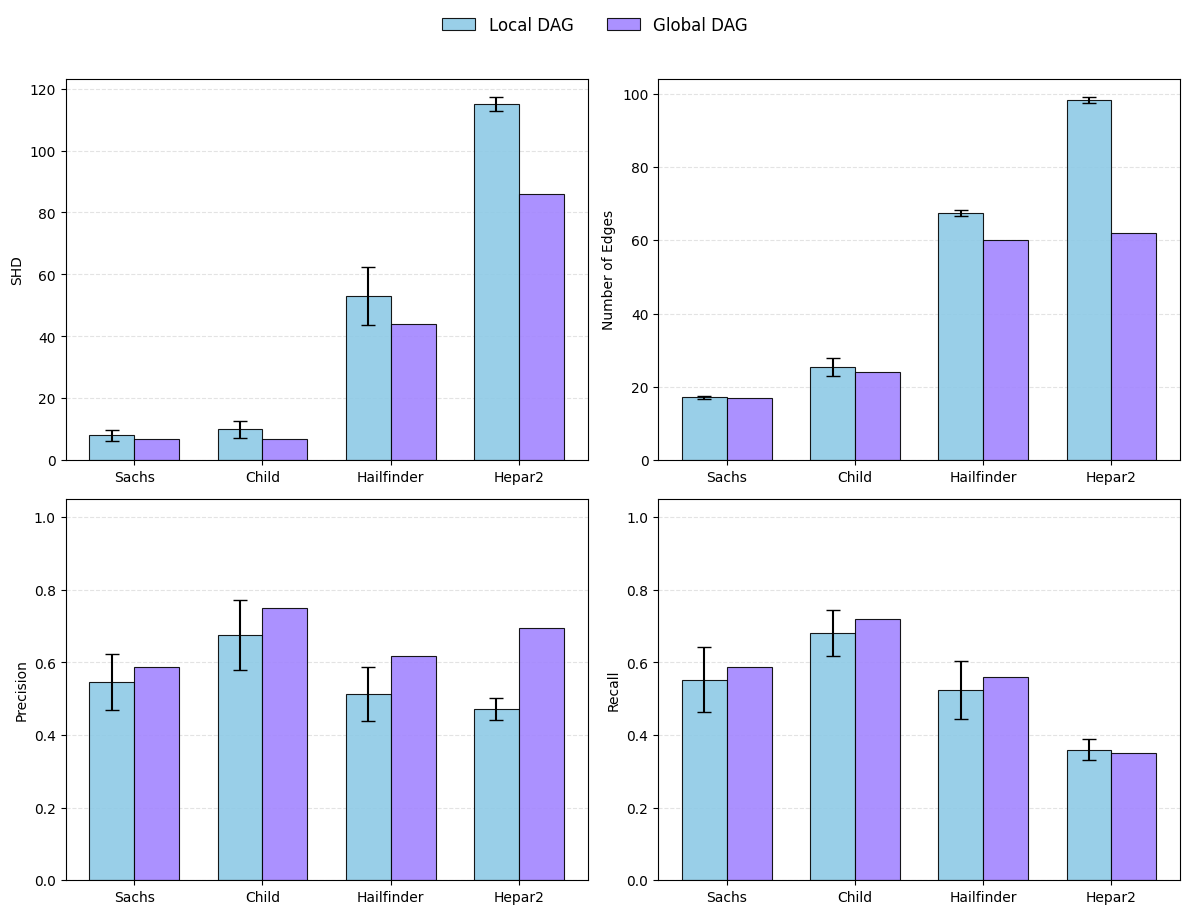

In [76]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------
# Data
# -----------------------------------

benchmarks = ["Sachs", "Child", "Hailfinder", "Hepar2"]

# Local DAG: mean values
local_shd = [8.00, 10.00, 53.00, 115]
local_edges = [17.20, 25.40, 67.40, 98.2]
local_precision = [0.5464, 0.6759, 0.5139, 0.471]
local_recall = [0.5529, 0.6800, 0.5242, 0.36]

# Local DAG: standard deviations
local_shd_std = [1.73, 2.65, 9.38, 2.236]
local_edges_std = [0.45, 2.41, 0.89, 0.836]
local_precision_std = [0.0780, 0.0962, 0.0740, 0.03]
local_recall_std = [0.0890, 0.0632, 0.0800, 0.029]

# Global DAG
global_shd = [7, 7, 44, 86]
global_edges = [17, 24, 60, 62]

# No Global Precision/Recall values provided
# Set Hepar2 to 0 as requested.
# Replace the first three values below if you have Global DAG results.
global_precision = [0.588, 0.75, 0.617, 0.694]
global_recall = [0.588, 0.72, 0.561, 0.35]


# -----------------------------------
# Colors
# -----------------------------------

local_color = "#8ECAE6"    # Pastel blue
global_color = "#a285ff"   # Pastel red


# -----------------------------------
# Plot settings
# -----------------------------------

x = np.arange(len(benchmarks))
width = 0.35

fig, axes = plt.subplots(2, 2, figsize=(12, 9))


# ===================================
# 1. SHD
# ===================================

axes[0, 0].bar(
    x - width / 2,
    local_shd,
    width,
    yerr=local_shd_std,
    capsize=5,
    color=local_color,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.9,
    label="Local DAG"
)

axes[0, 0].bar(
    x + width / 2,
    global_shd,
    width,
    color=global_color,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.9,
    label="Global DAG"
)

# axes[0, 0].set_title("SHD", fontsize=13)
axes[0, 0].set_ylabel("SHD")
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(benchmarks)
axes[0, 0].grid(axis="y", linestyle="--", alpha=0.35)
axes[0, 0].set_axisbelow(True)


# ===================================
# 2. Edges
# ===================================

axes[0, 1].bar(
    x - width / 2,
    local_edges,
    width,
    yerr=local_edges_std,
    capsize=5,
    color=local_color,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.9,
    label="Local DAG"
)

axes[0, 1].bar(
    x + width / 2,
    global_edges,
    width,
    color=global_color,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.9,
    label="Global DAG"
)

# axes[0, 1].set_title("Edges", fontsize=13)
axes[0, 1].set_ylabel("Number of Edges")
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(benchmarks)
axes[0, 1].grid(axis="y", linestyle="--", alpha=0.35)
axes[0, 1].set_axisbelow(True)


# ===================================
# 3. Precision
# ===================================

axes[1, 0].bar(
    x - width / 2,
    local_precision,
    width,
    yerr=local_precision_std,
    capsize=5,
    color=local_color,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.9,
    label="Local DAG"
)

axes[1, 0].bar(
    x + width / 2,
    global_precision,
    width,
    color=global_color,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.9,
    label="Global DAG"
)

# axes[1, 0].set_title("Precision", fontsize=13)
axes[1, 0].set_ylabel("Precision")
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(benchmarks)
axes[1, 0].set_ylim(0, 1.05)
axes[1, 0].grid(axis="y", linestyle="--", alpha=0.35)
axes[1, 0].set_axisbelow(True)


# ===================================
# 4. Recall
# ===================================

axes[1, 1].bar(
    x - width / 2,
    local_recall,
    width,
    yerr=local_recall_std,
    capsize=5,
    color=local_color,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.9,
    label="Local DAG"
)

axes[1, 1].bar(
    x + width / 2,
    global_recall,
    width,
    color=global_color,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.9,
    label="Global DAG"
)

# axes[1, 1].set_title("Recall", fontsize=13)
axes[1, 1].set_ylabel("Recall")
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(benchmarks)
axes[1, 1].set_ylim(0, 1.05)
axes[1, 1].grid(axis="y", linestyle="--", alpha=0.35)
axes[1, 1].set_axisbelow(True)


# -----------------------------------
# Shared legend
# -----------------------------------

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 1.02),
    frameon=False,
    fontsize=12
)


plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig(
    "local_vs_global.png",
    dpi=1000,
    bbox_inches="tight"
)

plt.show()